In [21]:
import pandas as pd
from ggsc.annot import annotate_cell_cycle
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
from scipy.stats import spearmanr
from hcrseq.scRNA.analysis import get_repair_df
import matplotlib.patches as mpatches

In [2]:
def annotate_cell_cycle(adata):
    cell_cycle_genes = np.unique(pd.read_csv('gs://ibm-cart-0/reference/regev_lab_cell_cycle_genes.txt',
                                                         header=None)[0])
    s_genes = cell_cycle_genes[:43]
    g2m_genes = cell_cycle_genes[43:]
                    
    cell_cycle_genes = [x for x in cell_cycle_genes if x in adata.var_names]

                            
    adata_cc = adata.copy()
    sc.pp.scale(adata_cc)

    sc.tl.score_genes_cell_cycle(adata_cc, s_genes=s_genes, g2m_genes=g2m_genes)

    adata.obs=adata_cc.obs
                                                
    return(adata)

In [15]:
adata = sc.read('../data/P3_clustered.v0.h5ad')

## Figure 5a - U-Map of cell line clustering

In [67]:
adata.obs['label'] = adata.obs['cell_line'].replace({'TK6_ATCC' : 'TK6 LIG4-/-','HELA' : 'HELA XPA-/-','U2OS' : 'U2OS OGG-/-','HAP1' : 'HAP1 MUTYH-/-'})
adata.obs['label_newline'] = adata.obs['label'].str.replace(' ','\n')

/tmp/ipykernel_269047/2065127511.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['label'] = adata.obs['cell_line'].replace({'TK6_ATCC' : 'TK6 LIG4-/-','HELA' : 'HELA XPA-/-','U2OS' : 'U2OS OGG-/-','HAP1' : 'HAP1 MUTYH-/-'})


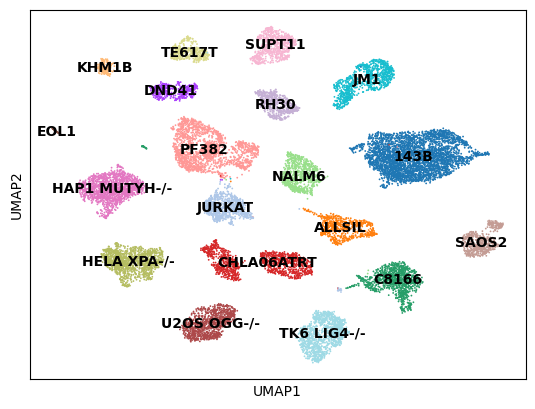

In [196]:
sc.pl.umap(adata,color='label',legend_loc='on data',show=False)
plt.title('')
plt.savefig('pdf/figure5a_scrna_umap_plot.pdf')

## Figure 5b - KO repair violins

/home/njharlen/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/njharlen/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/njharlen/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/njharlen/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


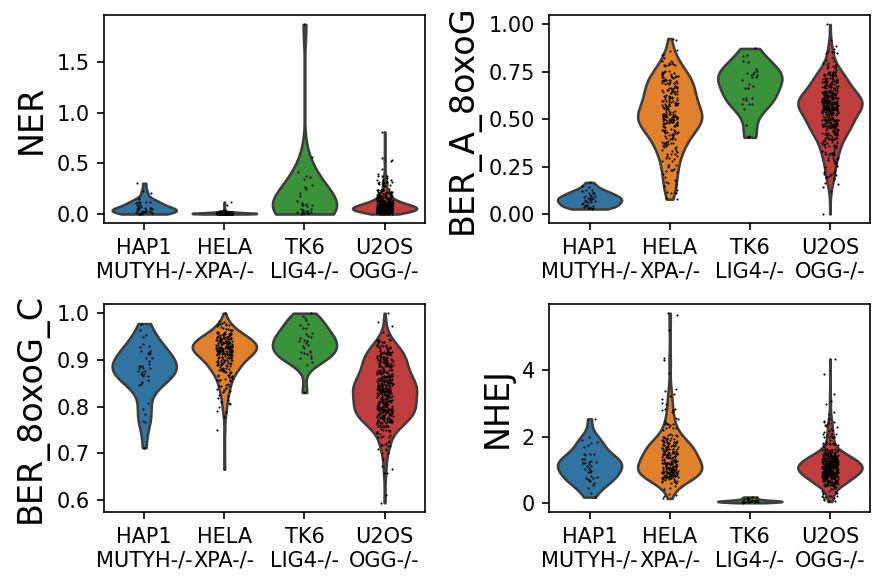

In [9]:
idx = adata.obs['label'].str.contains('-/-')&adata.obs['transfected']&(adata.obs['timepoint']=='2h')

f,ax = plt.subplots(2,2,figsize=(6,4))
ax = ax.reshape(-1)

pathway_map = {'NER' : 'NER',
                'BER_A_8oxoG' : 'BER (A:8oxoG)',
                'BER_8oxoG_C' : 'BER (8oxoG:C)',
                'NHEJ' : 'NHEJ'}

i=0
for pathway in pathway_map.keys():
    sc.pl.violin(adata[idx],pathway,
             groupby='label_newline',
             show=False,ax=ax[i])
    ax[i].set_xlabel('')
    i+=1
plt.tight_layout()
plt.savefig('pdf/figure5b_scrna_ko_lines.pdf')

## Figure 5c - heatmap of repair across WT cell lines

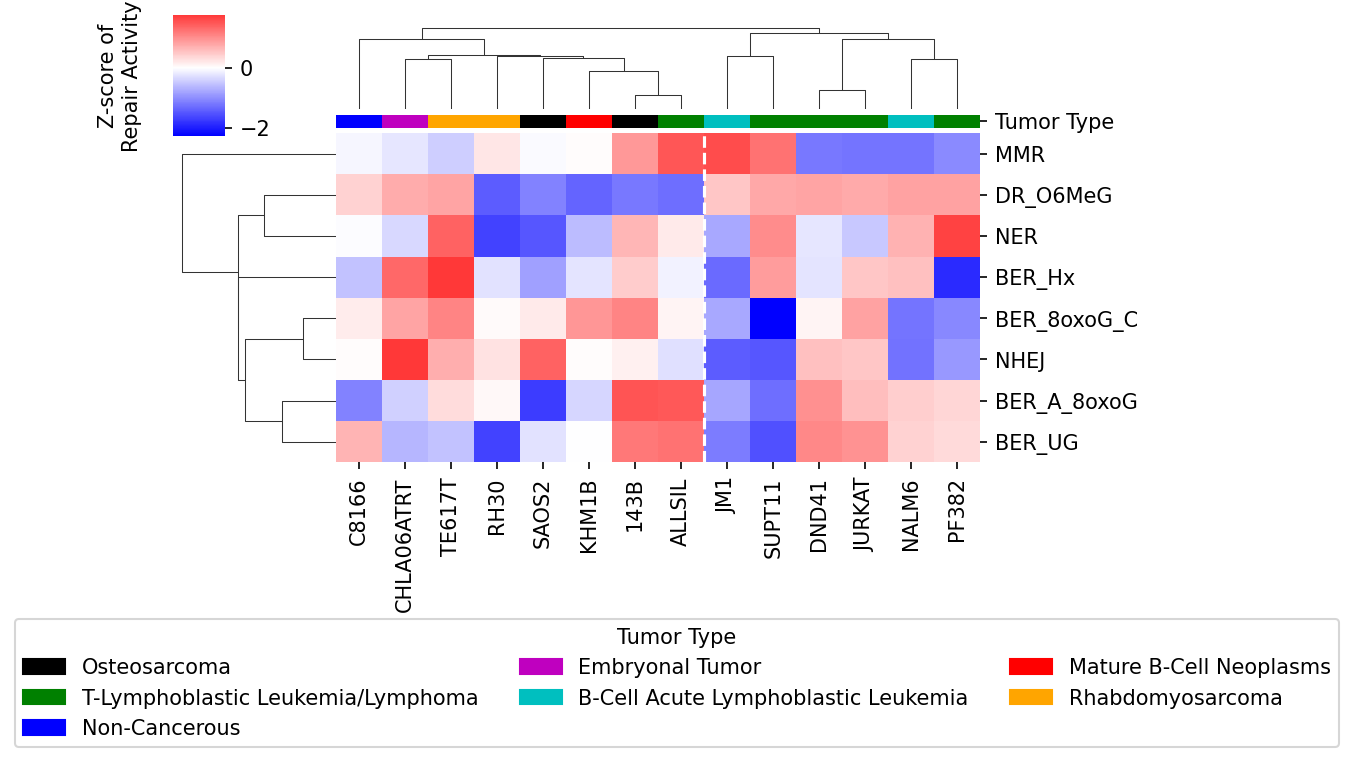

In [46]:
# Gather repair data
idx = ~adata.obs['cell_line'].isin(['HAP1','HELA','TK6_ATCC','U2OS'])

df = get_repair_df(adata[idx],groupby=['cell_line','timepoint'])
df = df[df['timepoint']=='2h']
df = df[df['n']>10]

X = df.set_index(['cell_line','pathway'])['repair'].unstack()

# Create color mapping

adata.uns['cell_line_info']['Tumor Type'] = adata.uns['cell_line_info']['OncotreePrimaryDisease']
key = 'Tumor Type'
value_map = adata.uns['cell_line_info'].loc[X.index][key]
unique_values = value_map.unique()
colors = list("kgbmcr") + ["orange"]
lut = dict(zip(unique_values, colors))
col_colors = value_map.map(lut)

# Create the clustermap
g = sns.clustermap(X.T, z_score=0, cmap='bwr', center=0, 
                   col_colors=col_colors, metric='correlation', method='single',figsize=(7,4.5))

# Add legend
legend_handles = [mpatches.Patch(color=c, label=l) for l, c in lut.items()]
g.fig.legend(handles=legend_handles, 
             title=key, 
             loc='upper center',         # The point of the legend box to align
             bbox_to_anchor=(0.5, 0.1),  # 0.5 is horizontal center, 0.05 is near the bottom
             ncol=3,                     # Organizes labels into columns to save vertical space
             bbox_transform=g.fig.transFigure)

# Adjust labels
g.ax_cbar.set_ylabel('Z-score of\nRepair Activity', fontsize=10)
g.ax_cbar.yaxis.set_label_position('left')
g.ax_cbar.yaxis.labelpad = 15
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')

g.ax_heatmap.axvline(8,linestyle='--',color='w')

plt.savefig('pdf/figure5c_scrna_repair_heatmap.pdf')

## Figure 5d - MGMT vs O6MeG repair

/tmp/ipykernel_269047/783641799.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata[idx,'MGMT'].to_df().join(adata.obs[idx]).groupby('cell_line')[['MGMT','DR_O6MeG','MMR']].mean()


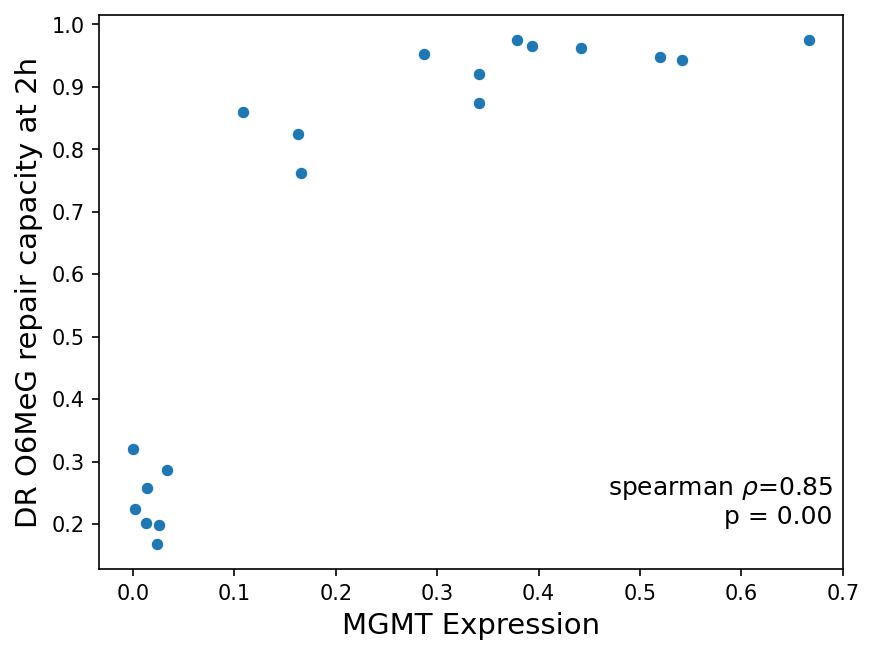

In [48]:
idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')

df = adata[idx,'MGMT'].to_df().join(adata.obs[idx]).groupby('cell_line')[['MGMT','DR_O6MeG','MMR']].mean()

sns.scatterplot(x="MGMT",y="DR_O6MeG",data=df)
plt.xlabel('MGMT Expression',fontsize=14)
plt.ylabel('DR O6MeG repair capacity at 2h',fontsize=14)

res = spearmanr(df['MGMT'],df['DR_O6MeG'])
plt.text(.69,.2,f'spearman $\\rho$={res[0]:.2f}\np = {res[1]:.2f}',ha='right',fontsize=12)

plt.savefig('pdf/figure5d_MGMT_O6MeG_correlation.pdf')

## Figure 5e - MSI data

In [57]:
msi_lines = ['NALM6','JURKAT','DND41','PF382']

In [58]:
msi_data = pd.read_excel('../data/NIHMS1522798-supplement-Supp_Table_1.xlsx')
msi_data['stripped_name'] = msi_data['CCLE_ID'].str.replace('_.*','',regex=True)
df = get_repair_df(adata)
df = df[(df['timepoint']=='2h')&(df['pathway']=='MMR')]

In [59]:
df = df.join(msi_data.set_index('stripped_name'),on='cell_line',how='left')

In [60]:
# From DepMap.org
df['alteration'] = 'None'
df.loc[df['cell_line']=='NALM6','alteration'] = 'MSH2del'
df.loc[df['cell_line']=='JURKAT','alteration'] = 'MSH2 p.R711*\nMSH6del'
df.loc[df['cell_line']=='DND41','alteration'] = 'MLH1splice'
df.loc[df['cell_line']=='PF382','alteration'] = 'MLH1 p.R79G\nMSH6 p.Y1006N'


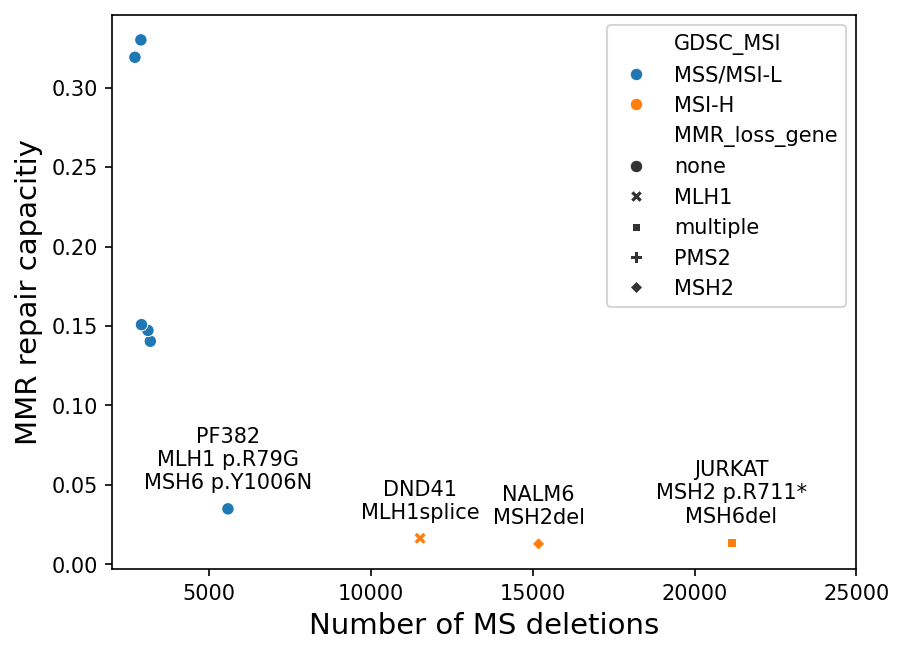

In [61]:
sns.scatterplot(x="ms_deletions_normed",
                y="repair",
                hue="GDSC_MSI",
                style='MMR_loss_gene',
                data=df)
plt.xlabel('Number of MS deletions',fontsize=14)
plt.ylabel('MMR repair capacitiy',fontsize=14)

plt.xlim([2000,25000])

for ind,row in df[df['alteration']!="None"].iterrows():
    plt.text(row["ms_deletions_normed"],
             row["repair"] + .01,
             row['cell_line'] + '\n' + row["alteration"],ha='center',va='bottom')
plt.savefig('pdf/figure5e_scrna_MSI_MMR_comparison.pdf')

## Figure 5f - U2OS cell cycle

In [62]:
adata = annotate_cell_cycle(adata)

/home/njharlen/anaconda3/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


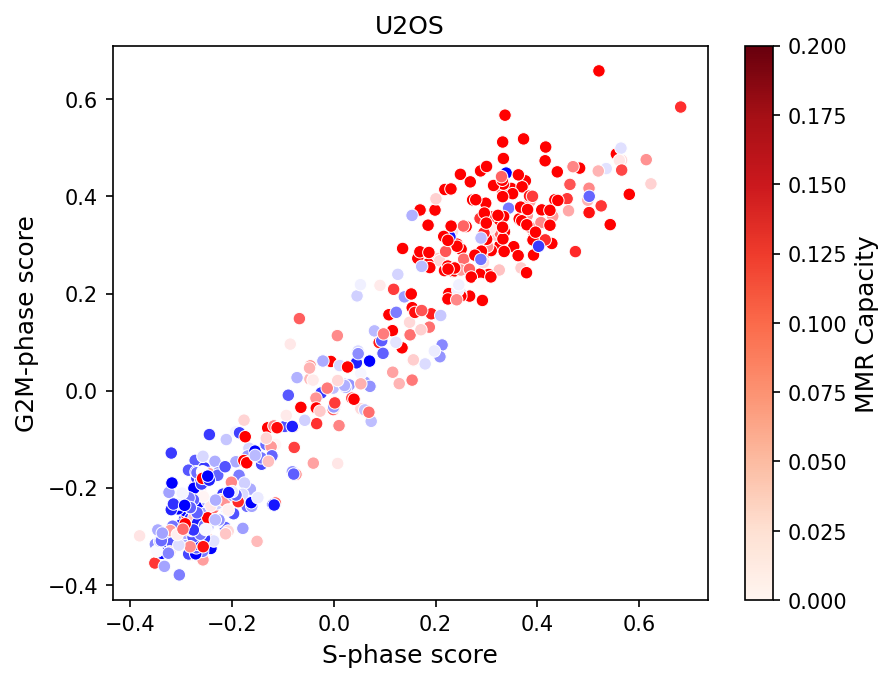

In [63]:
idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')&(adata.obs['cell_line']=='U2OS')

norm = plt.Normalize(0,.2)
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)

sns.scatterplot(x="S_score",y="G2M_score",hue="MMR",data=adata.obs[idx],hue_norm=norm,palette="bwr")

plt.legend().remove()
g=plt.gcf().colorbar(sm,ax=plt.gca())
plt.xlabel('S-phase score',fontsize=12)
plt.ylabel('G2M-phase score',fontsize=12)

g.set_label('MMR Capacity',fontsize=12)

plt.title('U2OS')

plt.savefig('pdf/figure5f_U2OS_cell_cycle_correlation.pdf')

## Figure 5g - MMR cell cycle boxplots

/tmp/ipykernel_269047/1128308770.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = adata.obs[idx].groupby(['cell_line','cycling_subset'])['MMR'].mean().reset_index()
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):


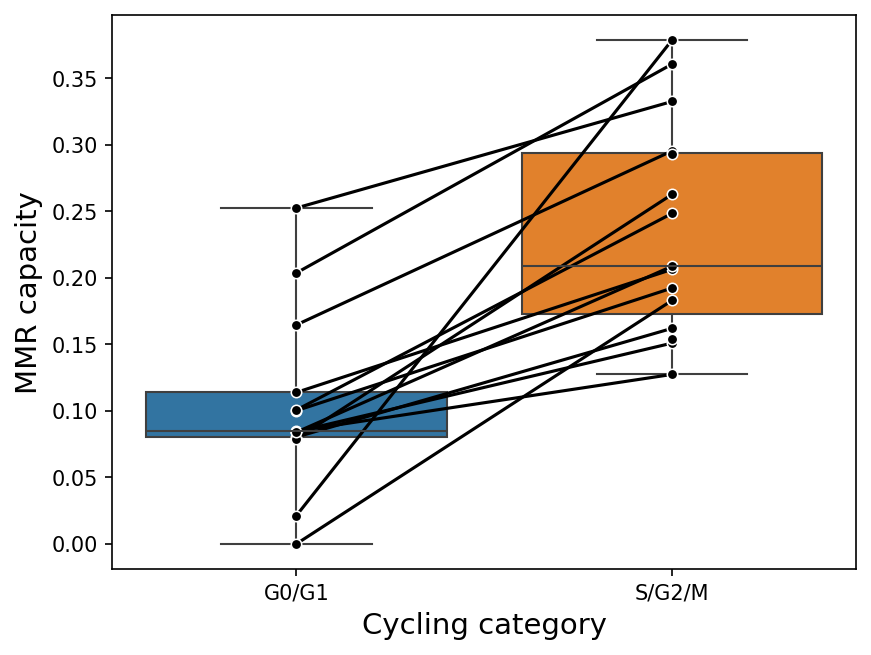

In [64]:
idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')&(~adata.obs['cell_line'].isin(msi_lines))

adata.obs['cycling_subset'] = adata.obs['phase'].isin(['G2M','S']).map({False : 'G0/G1',True : 'S/G2/M'})


x = adata.obs[idx].groupby(['cell_line','cycling_subset'])['MMR'].mean().reset_index()
sns.boxplot(x="cycling_subset",hue="cycling_subset",y="MMR",data=x,whis=100)
sns.lineplot(x="cycling_subset",y="MMR",units='cell_line',data=x,color='k',estimator=None,marker='o',markersize=5)
plt.ylabel('MMR capacity',fontsize=14)
plt.xlabel('Cycling category',fontsize=14)

plt.savefig('pdf/figure5g_overall_cell_cycle_boxplots.pdf')

## Figure 5h - BER deletions

/tmp/ipykernel_269047/2359352482.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata[idx].obs.groupby(['label','timepoint','condition'])[['GFP_BAR_007','BER_del']].sum()
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

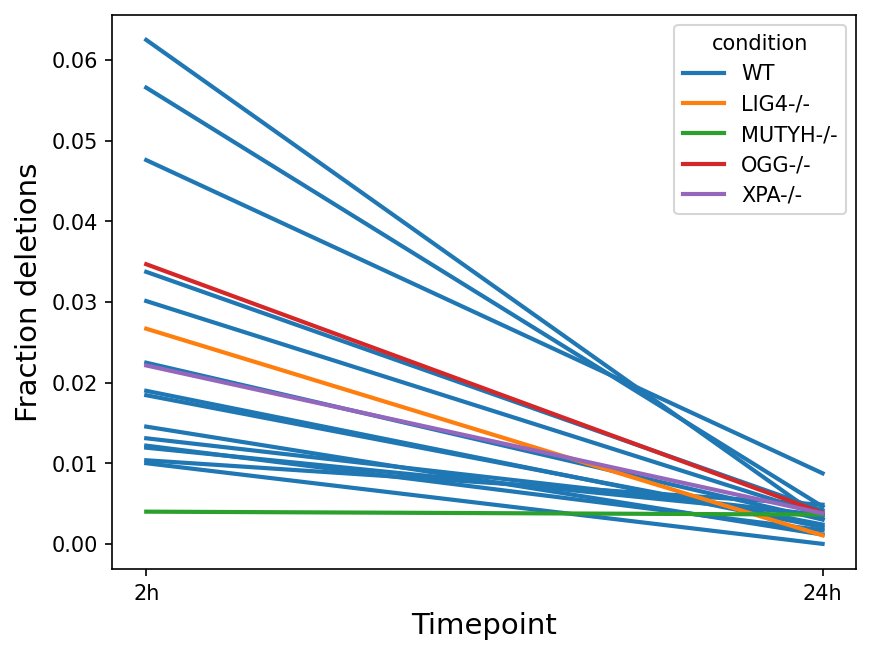

In [68]:
adata.obs['BER_del'] = adata.obsm['del_counts']['GFP_BAR_007']
adata.obs['condition'] = adata.obs['label'].str.split(' ',expand=True)[1].replace({None:'WT'})

adata.obs['condition'] = pd.Categorical(adata.obs['condition'],categories=['WT','LIG4-/-','MUTYH-/-','OGG-/-','XPA-/-'])

idx = adata.obs['transfected']
df = adata[idx].obs.groupby(['label','timepoint','condition'])[['GFP_BAR_007','BER_del']].sum()
df['f_del'] = df['BER_del']/df['GFP_BAR_007']

sns.lineplot(x='timepoint',y='f_del',data=df,hue="condition",linewidth=2,units='label',estimator=None)
plt.ylabel('Fraction deletions',fontsize=14)
plt.xlabel('Timepoint',fontsize=14)

plt.savefig('pdf/figure5h_scrna_ber_deletions.pdf')